# Engenharia de features

**Etapa:** construção da matriz causal

As features são recalculadas e conferidas para provar que usam somente informações disponíveis na origem. Random Forest e PLS compartilham as mesmas 12 variáveis.

**Entrada:** base bruta, variáveis externas, base modelável e protocolo  
**Resultado principal:** 12 features aprovadas, documentadas e livres de informação futura


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Validação causal e seleção das features

In [3]:
APPROVED_FEATURES = [
    "GOLD_PRICE",
    "TREASURY_10Y",
    "FED_FUNDS_RATE",
    "DOW_SIN",
    "DOW_COS",
    "MONTH_SIN",
    "MONTH_COS",
    "GOLD_LAG_1",
    "GOLD_LAG_5",
    "GOLD_LAG_20",
    "GOLD_ROLLING_MEAN_5",
    "GOLD_ROLLING_STD_5",
]

df = load_data()
protocol = load_protocol()
candidates = protocol["candidate_features"]
train = df.iloc[: protocol["splits"]["train_end"]].copy()

forbidden = {"DATE", "TARGET_DATE", "TARGET", "TARGET_UP", "DAY_OF_WEEK", "MONTH"}
assert forbidden.isdisjoint(candidates)
assert {"TREASURY_10Y", "FED_FUNDS_RATE"}.issubset(candidates)

raw_gold_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
raw_gold = pd.read_csv(raw_gold_path, sep=None, engine="python", parse_dates=["DATE"])
raw_gold["GOLD_PRICE"] = pd.to_numeric(raw_gold["VALUE"], errors="coerce")
raw_gold["GOLD_LAG_1_CHECK"] = raw_gold["GOLD_PRICE"].shift(1)
raw_gold["GOLD_LAG_5_CHECK"] = raw_gold["GOLD_PRICE"].shift(5)
raw_gold["GOLD_LAG_20_CHECK"] = raw_gold["GOLD_PRICE"].shift(20)
prior_gold = raw_gold["GOLD_PRICE"].shift(1)
raw_gold["GOLD_ROLLING_MEAN_5_CHECK"] = prior_gold.rolling(5).mean()
raw_gold["GOLD_ROLLING_STD_5_CHECK"] = prior_gold.rolling(5).std()



In [4]:
lag_checks = df.merge(
    raw_gold[
        [
            "DATE",
            "GOLD_LAG_1_CHECK",
            "GOLD_LAG_5_CHECK",
            "GOLD_LAG_20_CHECK",
            "GOLD_ROLLING_MEAN_5_CHECK",
            "GOLD_ROLLING_STD_5_CHECK",
        ]
    ],
    on="DATE",
    how="left",
    validate="one_to_one",
)

for feature in ["GOLD_LAG_1", "GOLD_LAG_5", "GOLD_LAG_20", "GOLD_ROLLING_MEAN_5", "GOLD_ROLLING_STD_5"]:
    assert np.allclose(lag_checks[feature], lag_checks[f"{feature}_CHECK"])

day_of_week = df["DATE"].dt.dayofweek
month = df["DATE"].dt.month
assert np.allclose(df["DOW_SIN"], np.sin(2 * np.pi * day_of_week / 7))
assert np.allclose(df["DOW_COS"], np.cos(2 * np.pi * day_of_week / 7))
assert np.allclose(df["MONTH_SIN"], np.sin(2 * np.pi * month / 12))
assert np.allclose(df["MONTH_COS"], np.cos(2 * np.pi * month / 12))

dgs10 = pd.read_csv(
    ROOT / "bases/grupo5-tratamento/dgs10.csv",
    sep=None,
    engine="python",
).rename(columns={"observation_date": "DATE", "DGS10": "TREASURY_10Y_CHECK"})
dff = pd.read_csv(
    ROOT / "bases/grupo5-tratamento/dff.csv",
    sep=None,
    engine="python",
).rename(columns={"observation_date": "DATE", "DFF": "FED_FUNDS_RATE_CHECK"})
dgs10["DATE"] = pd.to_datetime(dgs10["DATE"])
dff["DATE"] = pd.to_datetime(dff["DATE"])
dgs10["TREASURY_10Y_CHECK"] = pd.to_numeric(dgs10["TREASURY_10Y_CHECK"], errors="coerce")
dff["FED_FUNDS_RATE_CHECK"] = pd.to_numeric(dff["FED_FUNDS_RATE_CHECK"], errors="coerce")
external_checks = raw_gold[["DATE"]].merge(dgs10, on="DATE", how="left")
external_checks = external_checks.merge(dff, on="DATE", how="left")


In [5]:
external_check_columns = ["TREASURY_10Y_CHECK", "FED_FUNDS_RATE_CHECK"]
external_checks[external_check_columns] = external_checks[external_check_columns].ffill().shift(1)
external_checks = df.merge(
    external_checks[["DATE", *external_check_columns]],
    on="DATE",
    how="left",
    validate="one_to_one",
)
assert np.allclose(external_checks["TREASURY_10Y"], external_checks["TREASURY_10Y_CHECK"])
assert np.allclose(external_checks["FED_FUNDS_RATE"], external_checks["FED_FUNDS_RATE_CHECK"])

rules = {
    "GOLD_PRICE": "preço observado na origem",
    "TREASURY_10Y": "último valor disponível, preenchido para frente e defasado uma observação",
    "FED_FUNDS_RATE": "último valor disponível, preenchido para frente e defasado uma observação",
    "DOW_SIN": "calendário conhecido na origem, componente cíclica",
    "DOW_COS": "calendário conhecido na origem, componente cíclica",
    "MONTH_SIN": "calendário conhecido na origem, componente cíclica",
    "MONTH_COS": "calendário conhecido na origem, componente cíclica",
    "GOLD_LAG_1": "preço de uma observação anterior",
    "GOLD_LAG_5": "preço de cinco observações anteriores",
    "GOLD_LAG_20": "preço de vinte observações anteriores",
    "GOLD_ROLLING_MEAN_5": "média dos cinco preços anteriores",
    "GOLD_ROLLING_STD_5": "desvio padrão dos cinco preços anteriores",
}

target_correlations = train[candidates].corrwith(train["TARGET"])
evidence = pd.DataFrame(
    {
        "feature": candidates,
        "regra_causal": [rules[feature] for feature in candidates],
        "correlacao_com_target": [target_correlations[feature] for feature in candidates],
        "desvio_padrao": [train[feature].std() for feature in candidates],
        "nulos_no_treino": [int(train[feature].isna().sum()) for feature in candidates],
    }
).sort_values("correlacao_com_target", key=abs, ascending=False)

feature_correlations = train[candidates].corr()
pairs = []


,feature,regra_causal,correlacao_com_target,desvio_padrao,nulos_no_treino
0,GOLD_PRICE,preço observado na origem,0.9994,149.4355,0
7,GOLD_LAG_1,preço de uma observação anterior,0.9990,149.4325,0
10,GOLD_ROLLING_MEAN_5,média dos cinco preços anteriores,0.9983,149.4840,0
8,GOLD_LAG_5,preço de cinco observações anteriores,0.9968,149.6643,0
9,GOLD_LAG_20,preço de vinte observações anteriores,0.9889,150.1683,0
11,GOLD_ROLLING_STD_5,desvio padrão dos cinco preços anteriores,0.4850,4.1396,0
1,TREASURY_10Y,"último valor disponível, preenchido para frent...",0.4741,2.2395,0
2,FED_FUNDS_RATE,"último valor disponível, preenchido para frent...",0.3065,3.1111,0
6,MONTH_COS,"calendário conhecido na origem, componente cíc...",0.0416,0.6966,0
5,MONTH_SIN,"calendário conhecido na origem, componente cíc...",-0.0051,0.7158,0


,feature_1,feature_2,correlacao
0,GOLD_PRICE,GOLD_LAG_1,0.9995
8,GOLD_LAG_5,GOLD_ROLLING_MEAN_5,0.9994
6,GOLD_LAG_1,GOLD_ROLLING_MEAN_5,0.9993
3,GOLD_PRICE,GOLD_ROLLING_MEAN_5,0.9988
4,GOLD_LAG_1,GOLD_LAG_5,0.9979
1,GOLD_PRICE,GOLD_LAG_5,0.9972
7,GOLD_LAG_5,GOLD_LAG_20,0.9926
9,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,0.9920
5,GOLD_LAG_1,GOLD_LAG_20,0.9904
2,GOLD_PRICE,GOLD_LAG_20,0.9896


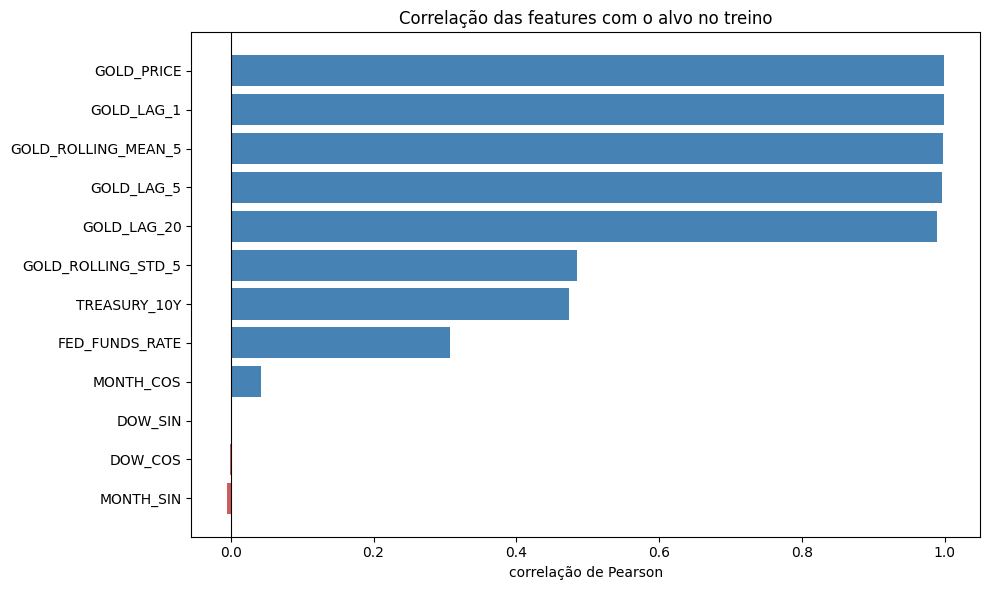

Features aprovadas e registradas.


In [6]:
for position, first in enumerate(candidates):
    for second in candidates[position + 1 :]:
        correlation = feature_correlations.loc[first, second]
        if abs(correlation) >= 0.90:
            pairs.append(
                {"feature_1": first, "feature_2": second, "correlacao": correlation}
            )

high_correlations = pd.DataFrame(pairs).sort_values("correlacao", key=abs, ascending=False)

display(evidence.round(4))
display(high_correlations.round(4))

evidence.to_csv(OUT / "feature_dictionary.csv", index=False)
high_correlations.to_csv(OUT / "feature_high_correlations.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
plot_data = evidence.sort_values("correlacao_com_target")
colors = ["steelblue" if value >= 0 else "indianred" for value in plot_data["correlacao_com_target"]]
ax.barh(plot_data["feature"], plot_data["correlacao_com_target"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação das features com o alvo no treino")
ax.set_xlabel("correlação de Pearson")
plt.tight_layout()
plt.savefig(OUT / "06_feature_target_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

if APPROVED_FEATURES is None:
    raise RuntimeError(
        "DECISÃO NECESSÁRIA: defina APPROVED_FEATURES. RF e PLS usarão a mesma lista."
    )

if not set(APPROVED_FEATURES).issubset(candidates):
    raise ValueError("Há feature fora do contrato causal.")

if len(APPROVED_FEATURES) != len(set(APPROVED_FEATURES)):
    raise ValueError("A lista de features contém duplicidades.")

protocol["decisions"]["features"] = APPROVED_FEATURES
save_protocol(protocol)
print("Features aprovadas e registradas.")

### Exemplo de lags e janelas

A amostra abaixo permite conferir visualmente preço, lags, rolling mean, rolling std e externas. Todas as colunas usam apenas informação disponível na origem.

In [ ]:
# Exemplo das features causais na base pronta
feature_sample = load_data()[['DATE', 'GOLD_PRICE', 'GOLD_LAG_1', 'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5', 'GOLD_ROLLING_STD_5', 'TREASURY_10Y', 'FED_FUNDS_RATE']].head(6)
display(feature_sample)

DATE,GOLD_PRICE,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TREASURY_10Y,FED_FUNDS_RATE
1968-04-29,38.55,38.50,38.30,38.0,38.29,0.163554,5.71,6.13
1968-04-30,39.10,38.55,38.05,37.6,38.34,0.201246,5.73,6.13
1968-05-01,39.10,39.10,38.35,37.7,38.55,0.329773,5.74,6.25
1968-05-02,39.25,39.10,38.25,36.7,38.70,0.382426,5.73,6.38
1968-05-03,39.60,39.25,38.50,37.2,38.90,0.348210,5.76,6.25
1968-05-06,39.70,39.60,38.55,37.0,39.12,0.378484,5.80,6.13


## 3. Dicionário técnico das features

In [7]:
# FINAL_FEATURE_DICTIONARY
# Dicionário técnico das 12 features efetivamente usadas por RF e PLS.

feature_metadata = {
    "GOLD_PRICE": {
        "tipo": "preço observado na origem",
        "calculo": "valor de GOLD_PRICE na DATE_ORIGIN",
        "informacao_usada": "preço do ouro disponível na origem",
        "risco_leakage": "baixo; exige manter a linha como origem e TARGET na observação seguinte",
    },
    "TREASURY_10Y": {
        "tipo": "variável externa defasada",
        "calculo": "left merge no calendário do ouro, forward fill e shift(1)",
        "informacao_usada": "último DGS10 disponível antes da origem",
        "risco_leakage": "baixo; não usar valor contemporâneo ainda não publicado nem backfill",
    },
    "FED_FUNDS_RATE": {
        "tipo": "variável externa defasada",
        "calculo": "left merge no calendário do ouro, forward fill e shift(1)",
        "informacao_usada": "último DFF disponível antes da origem",
        "risco_leakage": "baixo; não usar valor contemporâneo ainda não publicado nem backfill",
    },
    "DOW_SIN": {
        "tipo": "calendário cíclico",
        "calculo": "sin(2*pi*dia_da_semana/7)",
        "informacao_usada": "dia da semana da origem",
        "risco_leakage": "nenhum; calendário é conhecido antecipadamente",
    },
    "DOW_COS": {
        "tipo": "calendário cíclico",
        "calculo": "cos(2*pi*dia_da_semana/7)",
        "informacao_usada": "dia da semana da origem",
        "risco_leakage": "nenhum; calendário é conhecido antecipadamente",
    },
    "MONTH_SIN": {
        "tipo": "calendário cíclico",
        "calculo": "sin(2*pi*mês/12)",
        "informacao_usada": "mês da origem",
        "risco_leakage": "nenhum; calendário é conhecido antecipadamente",
    },
    "MONTH_COS": {
        "tipo": "calendário cíclico",
        "calculo": "cos(2*pi*mês/12)",
        "informacao_usada": "mês da origem",
        "risco_leakage": "nenhum; calendário é conhecido antecipadamente",
    },
    "GOLD_LAG_1": {
        "tipo": "lag de preço",
        "calculo": "GOLD_PRICE.shift(1) no calendário bruto do ouro",
        "informacao_usada": "preço de uma observação bruta anterior",
        "risco_leakage": "baixo; shift positivo impede uso do futuro",
    },
    "GOLD_LAG_5": {
        "tipo": "lag de preço",
        "calculo": "GOLD_PRICE.shift(5) no calendário bruto do ouro",
        "informacao_usada": "preço de cinco observações brutas anteriores",
        "risco_leakage": "baixo; shift positivo impede uso do futuro",
    },
    "GOLD_LAG_20": {
        "tipo": "lag de preço",
        "calculo": "GOLD_PRICE.shift(20) no calendário bruto do ouro",
        "informacao_usada": "preço de vinte observações brutas anteriores",
        "risco_leakage": "baixo; shift positivo impede uso do futuro",
    },
    "GOLD_ROLLING_MEAN_5": {
        "tipo": "janela móvel de preço",
        "calculo": "GOLD_PRICE.shift(1).rolling(5).mean()",
        "informacao_usada": "média dos cinco preços anteriores à origem",
        "risco_leakage": "baixo; janela começa após shift(1)",
    },
    "GOLD_ROLLING_STD_5": {
        "tipo": "janela móvel de volatilidade",
        "calculo": "GOLD_PRICE.shift(1).rolling(5).std()",
        "informacao_usada": "desvio padrão dos cinco preços anteriores à origem",
        "risco_leakage": "baixo; janela começa após shift(1)",
    },
}



In [8]:
approved = protocol["decisions"]["features"]
assert approved == APPROVED_FEATURES
assert len(approved) == 12
assert "TARGET" not in approved and "TARGET_UP" not in approved

technical_dictionary = pd.DataFrame(
    [
        {
            "nome": feature,
            **feature_metadata[feature],
            "conhecida_na_origem": "sim",
            "decisao_final": "incluída em RF e PLS",
            "correlacao_com_target_treino": float(target_correlations[feature]),
            "nulos_no_treino": int(train[feature].isna().sum()),
        }
        for feature in approved
    ]
)

technical_dictionary.to_csv(OUT / "feature_dictionary.csv", index=False)
display(technical_dictionary)
print("Dicionário técnico consolidado com as 12 features reais de RF e PLS.")

,nome,tipo,calculo,informacao_usada,risco_leakage,conhecida_na_origem,decisao_final,correlacao_com_target_treino,nulos_no_treino
0,GOLD_PRICE,preço observado na origem,valor de GOLD_PRICE na DATE_ORIGIN,preço do ouro disponível na origem,baixo; exige manter a linha como origem e TARG...,sim,incluída em RF e PLS,0.999447,0
1,TREASURY_10Y,variável externa defasada,"left merge no calendário do ouro, forward fill...",último DGS10 disponível antes da origem,baixo; não usar valor contemporâneo ainda não ...,sim,incluída em RF e PLS,0.474059,0
2,FED_FUNDS_RATE,variável externa defasada,"left merge no calendário do ouro, forward fill...",último DFF disponível antes da origem,baixo; não usar valor contemporâneo ainda não ...,sim,incluída em RF e PLS,0.306484,0
3,DOW_SIN,calendário cíclico,sin(2*pi*dia_da_semana/7),dia da semana da origem,nenhum; calendário é conhecido antecipadamente,sim,incluída em RF e PLS,0.001071,0
4,DOW_COS,calendário cíclico,cos(2*pi*dia_da_semana/7),dia da semana da origem,nenhum; calendário é conhecido antecipadamente,sim,incluída em RF e PLS,-0.001501,0
5,MONTH_SIN,calendário cíclico,sin(2*pi*mês/12),mês da origem,nenhum; calendário é conhecido antecipadamente,sim,incluída em RF e PLS,-0.005073,0
6,MONTH_COS,calendário cíclico,cos(2*pi*mês/12),mês da origem,nenhum; calendário é conhecido antecipadamente,sim,incluída em RF e PLS,0.041597,0
7,GOLD_LAG_1,lag de preço,GOLD_PRICE.shift(1) no calendário bruto do ouro,preço de uma observação bruta anterior,baixo; shift positivo impede uso do futuro,sim,incluída em RF e PLS,0.999003,0
8,GOLD_LAG_5,lag de preço,GOLD_PRICE.shift(5) no calendário bruto do ouro,preço de cinco observações brutas anteriores,baixo; shift positivo impede uso do futuro,sim,incluída em RF e PLS,0.996760,0
9,GOLD_LAG_20,lag de preço,GOLD_PRICE.shift(20) no calendário bruto do ouro,preço de vinte observações brutas anteriores,baixo; shift positivo impede uso do futuro,sim,incluída em RF e PLS,0.988941,0


Dicionário técnico consolidado com as 12 features reais de RF e PLS.


## Interpretação

Preço atual, lags, janelas móveis, calendário cíclico e externas defasadas formam a matriz final. `TARGET` e `TARGET_UP` permanecem fora das features.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/feature_dictionary.csv`
- `outputs/feature_high_correlations.csv`
- `outputs/06_feature_target_correlations.png`